# Attention Is All You Need — 论文核心理解

本笔记聚焦四个核心问题：
1. **Attention 的计算逻辑** — Q/K/V 怎么计算，Softmax 归一化，多头注意力
2. **为什么可以替代 RNN** — 信息传递路径、梯度问题、长距离依赖
3. **Transformer 的模块堆叠结构** — Encoder/Decoder 的内部组成
4. **并行计算的优势** — 为什么 Transformer 比 RNN 快

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams['font.family'] = 'Arial Unicode MS'
plt.rcParams['figure.dpi'] = 120

---
## 1. Attention 的计算逻辑

### 1.1 直觉理解：带权重的「查询-检索」

把 Attention 想成一个**模糊数据库查询**：
- **Query (Q)**：你想查询的内容（"我想找什么"）
- **Key (K)**：数据库里每条记录的索引（"我是什么"）
- **Value (V)**：数据库里每条记录的实际值（"我的内容是什么"）

步骤：
1. 用 Q 和每个 K 做内积 → 得到「相关性分数」
2. 用 $\sqrt{d_k}$ 缩放，防止内积过大使 Softmax 梯度消失
3. Softmax 归一化 → 得到「注意力权重」（加和为 1 的概率分布）
4. 用权重加权求和 V → 输出

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

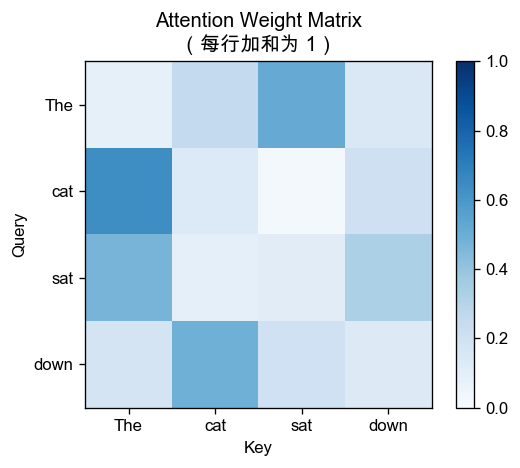

注意力权重（每行加和）: [1. 1. 1. 1.]
输出 shape: (4, 8)


In [11]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Q: (seq_len_q, d_k)
    K: (seq_len_k, d_k)
    V: (seq_len_k, d_v)
    """
    d_k = Q.shape[-1]

    # Step 1: 内积相似度  (seq_len_q, seq_len_k)
    scores = Q @ K.T / np.sqrt(d_k)

    # Step 2 (可选): mask 掉不该看的位置（Decoder 中用到）
    if mask is not None:
        scores = np.where(mask == 0, -1e9, scores)

    # Step 3: Softmax 归一化
    scores_exp = np.exp(scores - scores.max(axis=-1, keepdims=True))  # 数值稳定
    attn_weights = scores_exp / scores_exp.sum(axis=-1, keepdims=True)

    # Step 4: 加权求和 V
    output = attn_weights @ V
    return output, attn_weights


# ── 小例子：4 个词，d_k=d_v=8 ──
np.random.seed(42)
seq_len, d_k, d_v = 4, 8, 8
Q = np.random.randn(seq_len, d_k)
K = np.random.randn(seq_len, d_k)
V = np.random.randn(seq_len, d_v)

output, attn_weights = scaled_dot_product_attention(Q, K, V)

# 可视化注意力权重矩阵
tokens = ["The", "cat", "sat", "down"]
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(attn_weights, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(seq_len)); ax.set_xticklabels(tokens)
ax.set_yticks(range(seq_len)); ax.set_yticklabels(tokens)
ax.set_xlabel("Key"); ax.set_ylabel("Query")
ax.set_title("Attention Weight Matrix\n（每行加和为 1）")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

print("注意力权重（每行加和）:", attn_weights.sum(axis=-1).round(4))

print("输出 shape:", output.shape)

### 1.2 为什么要除以 $\sqrt{d_k}$？

若 Q 和 K 的元素均值为 0、方差为 1，则 $QK^T$ 的元素方差为 $d_k$。  
维度越大，内积越大，Softmax 的输入越极端，梯度趋近于 0。  
除以 $\sqrt{d_k}$ 后，方差重新变为 1，Softmax 处于敏感区间。

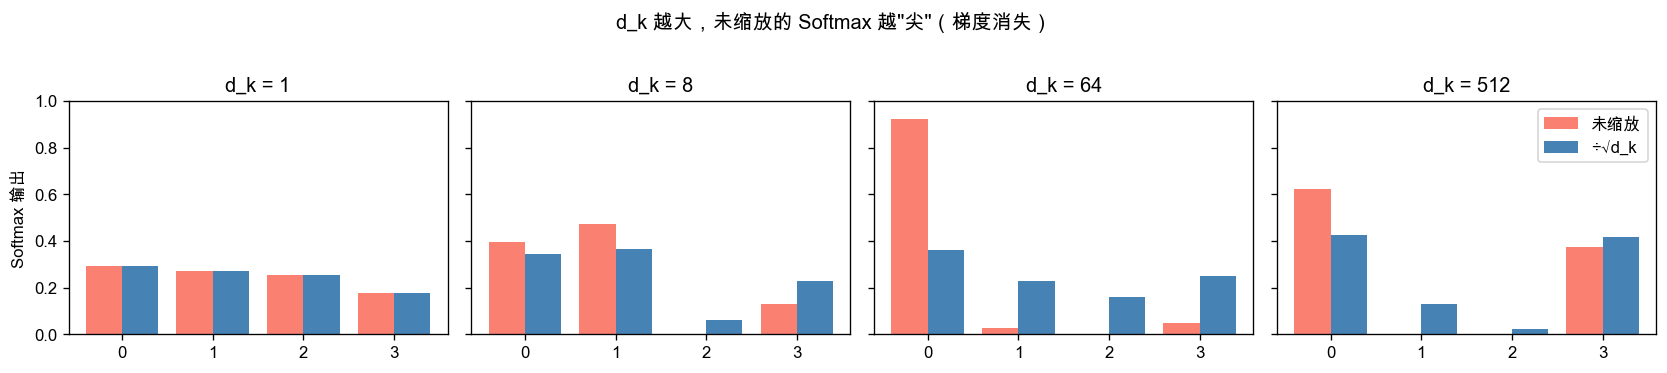

In [3]:
def softmax(x):
    e = np.exp(x - x.max())
    return e / e.sum()

dims = [1, 8, 64, 512]
fig, axes = plt.subplots(1, len(dims), figsize=(14, 3), sharey=True)
for ax, d in zip(axes, dims):
    q = np.random.randn(d)
    k = np.random.randn(4, d)   # 4 个 key
    raw   = softmax(q @ k.T)            # 未缩放
    scaled = softmax(q @ k.T / np.sqrt(d))  # 缩放后
    x = np.arange(4)
    ax.bar(x - 0.2, raw,    0.4, label='未缩放', color='salmon')
    ax.bar(x + 0.2, scaled, 0.4, label='÷√d_k', color='steelblue')
    ax.set_title(f'd_k = {d}')
    ax.set_xticks(x)
    ax.set_ylim(0, 1)
    if d == 1: ax.set_ylabel('Softmax 输出')

axes[-1].legend()
plt.suptitle('d_k 越大，未缩放的 Softmax 越"尖"（梯度消失）', y=1.02)
plt.tight_layout()
plt.show()

### 1.3 Multi-Head Attention（多头注意力）

单头注意力只能学一种「关注模式」（如语法依赖）。  
**多头注意力**让模型同时从 h 个子空间学习不同关注模式（如语法 + 语义 + 指代）：

$$\text{MultiHead}(Q,K,V) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h)\,W^O$$
$$\text{head}_i = \text{Attention}(QW_i^Q,\; KW_i^K,\; VW_i^V)$$

每个头的维度 $d_k = d_{\text{model}} / h$，总计算量不变。

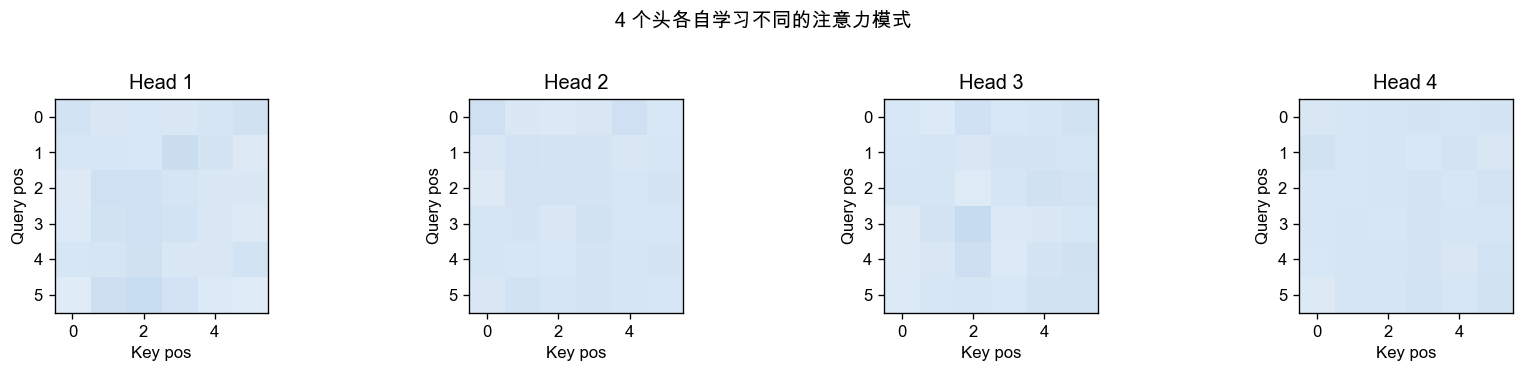

MultiHead 输出 shape: (6, 16)


In [4]:
def multi_head_attention(Q, K, V, num_heads, d_model):
    assert d_model % num_heads == 0
    d_k = d_model // num_heads
    seq_len = Q.shape[0]

    # 为每个头随机初始化投影权重（实际训练中通过反向传播学习）
    np.random.seed(0)
    Wq = [np.random.randn(d_model, d_k) * 0.1 for _ in range(num_heads)]
    Wk = [np.random.randn(d_model, d_k) * 0.1 for _ in range(num_heads)]
    Wv = [np.random.randn(d_model, d_k) * 0.1 for _ in range(num_heads)]
    Wo = np.random.randn(d_model, d_model) * 0.1

    head_outputs = []
    all_weights  = []
    for i in range(num_heads):
        Qi = Q @ Wq[i]   # (seq_len, d_k)
        Ki = K @ Wk[i]
        Vi = V @ Wv[i]
        out_i, w_i = scaled_dot_product_attention(Qi, Ki, Vi)
        head_outputs.append(out_i)
        all_weights.append(w_i)

    # Concat + 线性投影
    concat = np.concatenate(head_outputs, axis=-1)  # (seq_len, d_model)
    output = concat @ Wo
    return output, all_weights


d_model, num_heads, seq_len = 16, 4, 6
Q = K = V = np.random.randn(seq_len, d_model)   # Self-Attention: Q=K=V
output, all_weights = multi_head_attention(Q, K, V, num_heads, d_model)

# 可视化各头的注意力模式
fig, axes = plt.subplots(1, num_heads, figsize=(14, 3))
for i, (ax, w) in enumerate(zip(axes, all_weights)):
    ax.imshow(w, cmap='Blues', vmin=0, vmax=1)
    ax.set_title(f'Head {i+1}')
    ax.set_xlabel('Key pos'); ax.set_ylabel('Query pos')
plt.suptitle('4 个头各自学习不同的注意力模式', y=1.02)
plt.tight_layout()
plt.show()
print("MultiHead 输出 shape:", output.shape)

---
## 2. 为什么 Attention 可以替代 RNN

### 2.1 RNN 的核心瓶颈

RNN 处理序列时，信息必须通过隐状态**逐步传递**：

```
h1 → h2 → h3 → h4 → h5 → h6
↑    ↑    ↑    ↑    ↑    ↑
x1   x2   x3   x4   x5   x6
```

若想让 `x1` 影响 `x6` 的输出，信息必须经过 5 步「中转」，每一步都可能丢失信息（乘以权重矩阵后通过激活函数压缩）。

**两大问题**：
1. **长距离依赖退化**：路径越长，早期信息越难保留
2. **梯度消失/爆炸**：反向传播时梯度需乘以 $n$ 个 Jacobian 矩阵，$n$ 大时极不稳定

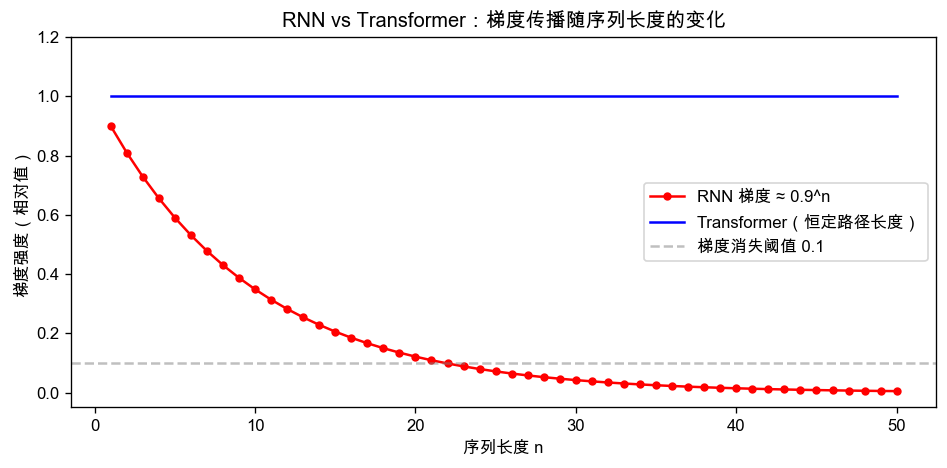

In [5]:
# ── 演示 RNN 梯度随序列长度的衰减 ──
seq_lengths = np.arange(1, 51)
w = 0.9  # 假设每步权重 < 1（常见情况）

# RNN: 梯度 ≈ w^n
rnn_grad = w ** seq_lengths

# Transformer: 任意两个位置之间只有 1 步（直接 Attention）
transformer_grad = np.ones_like(seq_lengths, dtype=float)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(seq_lengths, rnn_grad,        'r-o', ms=4, label=f'RNN 梯度 ≈ {w}^n')
ax.plot(seq_lengths, transformer_grad,'b-',        label='Transformer（恒定路径长度）')
ax.axhline(0.1, color='gray', linestyle='--', alpha=0.5, label='梯度消失阈值 0.1')
ax.set_xlabel('序列长度 n')
ax.set_ylabel('梯度强度（相对值）')
ax.set_title('RNN vs Transformer：梯度传播随序列长度的变化')
ax.legend()
ax.set_ylim(-0.05, 1.2)
plt.tight_layout()
plt.show()

### 2.2 Attention 如何解决这个问题

Self-Attention 中，**任意两个位置直接建立连接**，信息传递路径长度恒为 **O(1)**：

```
x1  x2  x3  x4  x5  x6
 \  |  / \  |  / 
  每个位置直接关注所有其他位置
```

| 模型 | 任意两位置间路径长度 | 每层计算复杂度 | 是否可并行 |
|------|---------------------|---------------|------------|
| RNN  | O(n)                | O(n · d²)     | ✗ 串行     |
| Self-Attention | O(1)     | O(n² · d)     | ✓ 全并行   |
| 卷积 (CNN)     | O(log n) | O(k · n · d²) | ✓ 可并行   |

> 当序列长度 $n < d$（现代 LLM 中几乎总是如此），Attention 的计算量 $O(n^2 d)$ 小于 RNN 的 $O(n d^2)$。

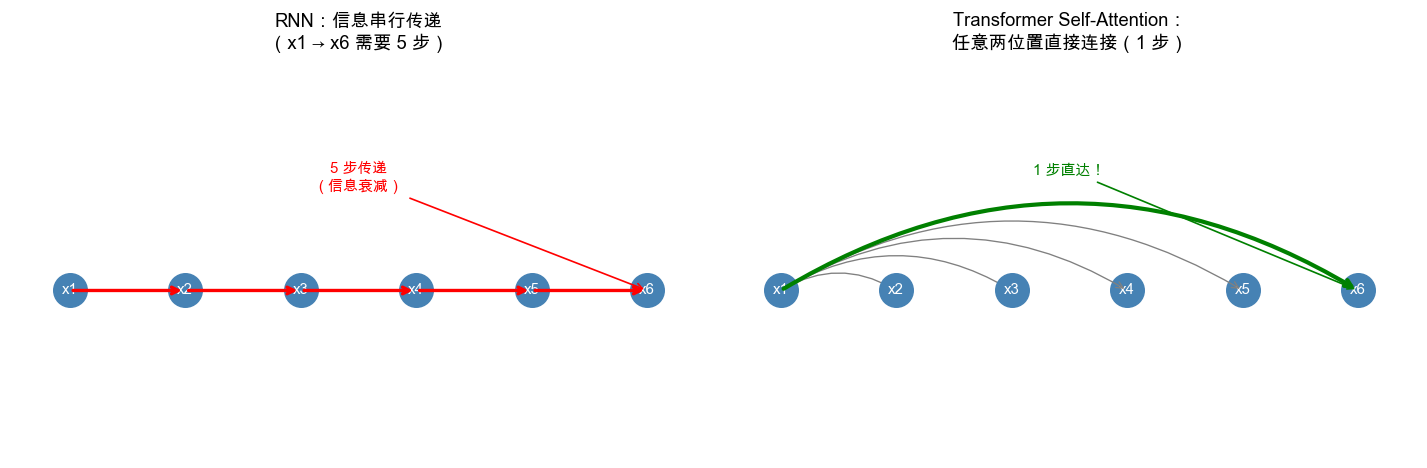

In [6]:
# ── 可视化：信息从 x1 到 x6 的传播路径 ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

n = 6
x_pos = np.arange(n)

# RNN: 串行链式连接
ax1.set_title('RNN：信息串行传递\n（x1 → x6 需要 5 步）', fontsize=11)
for i in x_pos:
    ax1.plot(i, 0.5, 'o', color='steelblue', ms=20, zorder=3)
    ax1.text(i, 0.5, f'x{i+1}', ha='center', va='center', color='white', fontsize=9)
for i in range(n - 1):
    ax1.annotate('', xy=(i+1, 0.5), xytext=(i, 0.5),
                 arrowprops=dict(arrowstyle='->', color='red', lw=2))
ax1.annotate('5 步传递\n（信息衰减）', xy=(5, 0.5), xytext=(2.5, 0.8),
             ha='center', color='red', fontsize=9,
             arrowprops=dict(arrowstyle='->', color='red'))
ax1.set_xlim(-0.5, 5.5); ax1.set_ylim(0, 1.2); ax1.axis('off')

# Transformer: 全连接 Attention
ax2.set_title('Transformer Self-Attention：\n任意两位置直接连接（1 步）', fontsize=11)
for i in x_pos:
    ax2.plot(i, 0.5, 'o', color='steelblue', ms=20, zorder=3)
    ax2.text(i, 0.5, f'x{i+1}', ha='center', va='center', color='white', fontsize=9)
# 只画从 x1 出发的连接（高亮）
for j in range(1, n):
    alpha = 0.3 if j > 1 else 0.9
    color = 'green' if j == n-1 else 'gray'
    lw    = 2.5 if j == n-1 else 0.8
    ax2.annotate('', xy=(j, 0.5), xytext=(0, 0.5),
                 arrowprops=dict(arrowstyle='->', color=color, lw=lw,
                                 connectionstyle='arc3,rad=-0.3'),
                 zorder=j)
ax2.annotate('1 步直达！', xy=(5, 0.5), xytext=(2.5, 0.85),
             ha='center', color='green', fontsize=9,
             arrowprops=dict(arrowstyle='->', color='green'))
ax2.set_xlim(-0.5, 5.5); ax2.set_ylim(0, 1.2); ax2.axis('off')

plt.tight_layout()
plt.show()

---
## 3. Transformer 的模块堆叠结构

### 3.1 整体架构：Encoder-Decoder

```
          输出（shifted right）
               ↓
    ┌──────────────────────┐
    │  Output Embedding +  │
    │  Positional Encoding │
    └──────────┬───────────┘
               │        ← 来自 Encoder 的 K, V
    ┌──────────▼───────────┐
    │   Decoder Block × N  │  ← 含 3 个子层
    └──────────┬───────────┘
               │
    ┌──────────▼───────────┐
    │  Linear + Softmax    │
    └──────────────────────┘
               ↑
    ┌──────────────────────┐
    │   Encoder Block × N  │  ← 含 2 个子层
    └──────────────────────┘
               ↑
    ┌──────────────────────┐
    │  Input Embedding +   │
    │  Positional Encoding │
    └──────────────────────┘
               ↑
             输入序列
```

### 3.2 每个子层的通用结构：残差连接 + Layer Norm

$$\text{子层输出} = \text{LayerNorm}(x + \text{SubLayer}(x))$$

残差连接（`x + ...`）的作用：
- 让梯度可以直接跳过若干层（类似 ResNet）
- 使堆叠 N 层成为可能（论文中 N=6）

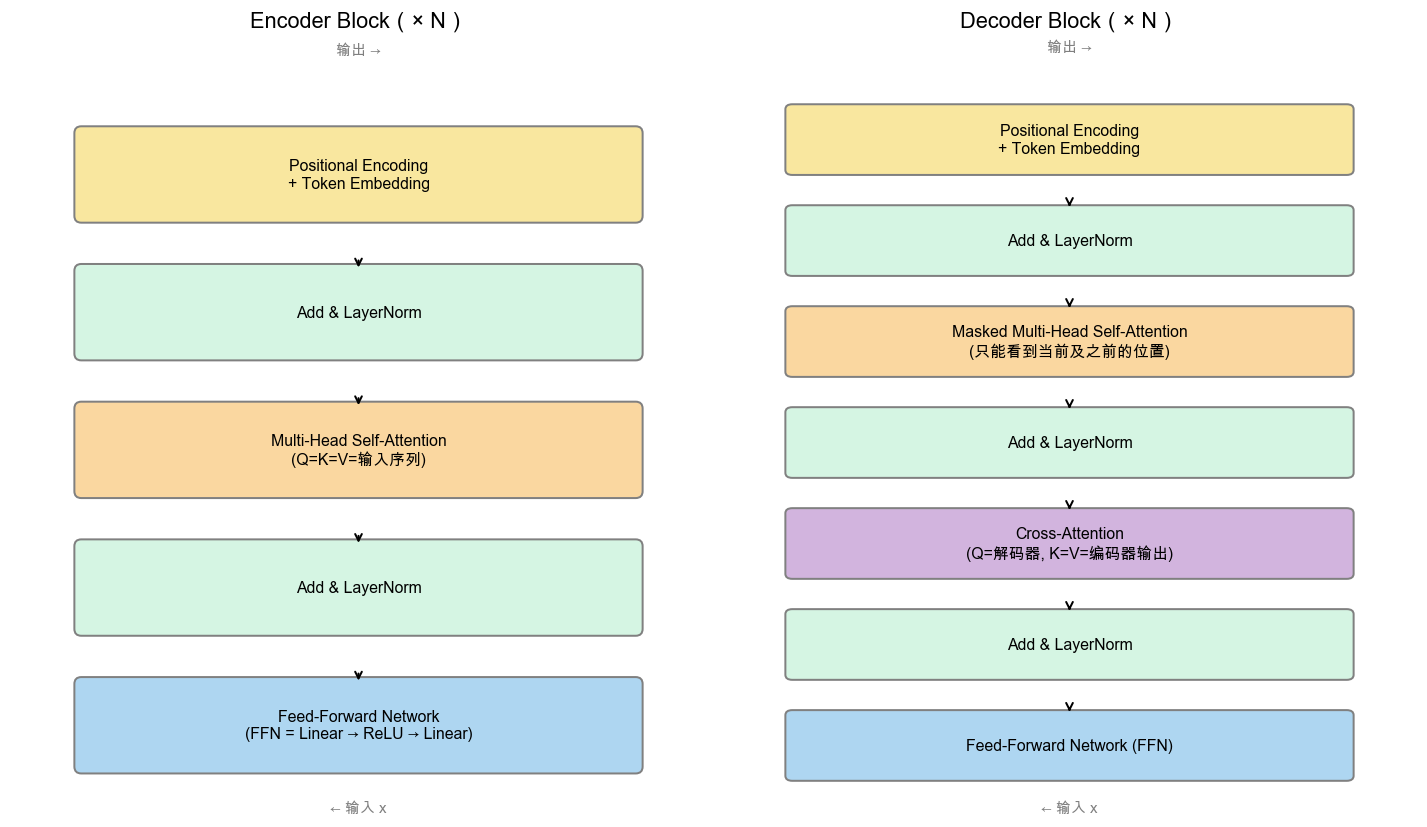

In [7]:
# ── 可视化 Encoder Block 和 Decoder Block 的内部结构 ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 7))

def draw_block(ax, title, layers):
    """layers: list of (label, color) from bottom to top"""
    ax.set_xlim(0, 10); ax.set_ylim(0, len(layers) * 2 + 1)
    ax.axis('off')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    for i, (label, color) in enumerate(layers):
        y = i * 2 + 0.5
        rect = mpatches.FancyBboxPatch((1, y), 8, 1.2,
                                        boxstyle="round,pad=0.1",
                                        facecolor=color, edgecolor='gray', lw=1.2)
        ax.add_patch(rect)
        ax.text(5, y + 0.6, label, ha='center', va='center', fontsize=9.5)
        # 箭头
        if i < len(layers) - 1:
            ax.annotate('', xy=(5, y + 1.2), xytext=(5, y + 2.0 - 0.6),
                        arrowprops=dict(arrowstyle='->', lw=1.2))
    # 输入/输出标签
    ax.text(5, 0, '← 输入 x', ha='center', va='top', color='gray', fontsize=9)
    ax.text(5, len(layers)*2 + 0.8, '输出 →', ha='center', va='bottom', color='gray', fontsize=9)

encoder_layers = [
    ('Feed-Forward Network\n(FFN = Linear → ReLU → Linear)', '#AED6F1'),
    ('Add & LayerNorm', '#D5F5E3'),
    ('Multi-Head Self-Attention\n(Q=K=V=输入序列)', '#FAD7A0'),
    ('Add & LayerNorm', '#D5F5E3'),
    ('Positional Encoding\n+ Token Embedding', '#F9E79F'),
]

decoder_layers = [
    ('Feed-Forward Network (FFN)', '#AED6F1'),
    ('Add & LayerNorm', '#D5F5E3'),
    ('Cross-Attention\n(Q=解码器, K=V=编码器输出)', '#D2B4DE'),
    ('Add & LayerNorm', '#D5F5E3'),
    ('Masked Multi-Head Self-Attention\n(只能看到当前及之前的位置)', '#FAD7A0'),
    ('Add & LayerNorm', '#D5F5E3'),
    ('Positional Encoding\n+ Token Embedding', '#F9E79F'),
]

draw_block(ax1, 'Encoder Block（× N）', encoder_layers)
draw_block(ax2, 'Decoder Block（× N）', decoder_layers)
plt.tight_layout()
plt.show()

### 3.3 Positional Encoding —— 告诉模型词的位置

Attention 本身是**置换不变**的（打乱输入顺序，输出不变）。  
论文通过**正弦/余弦编码**注入位置信息：

$$PE_{(pos,\,2i)}   = \sin\!\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right)$$
$$PE_{(pos,\,2i+1)} = \cos\!\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right)$$

好处：不同频率的波形让模型能区分任意长度的相对位置，且能外推到训练时未见过的序列长度。

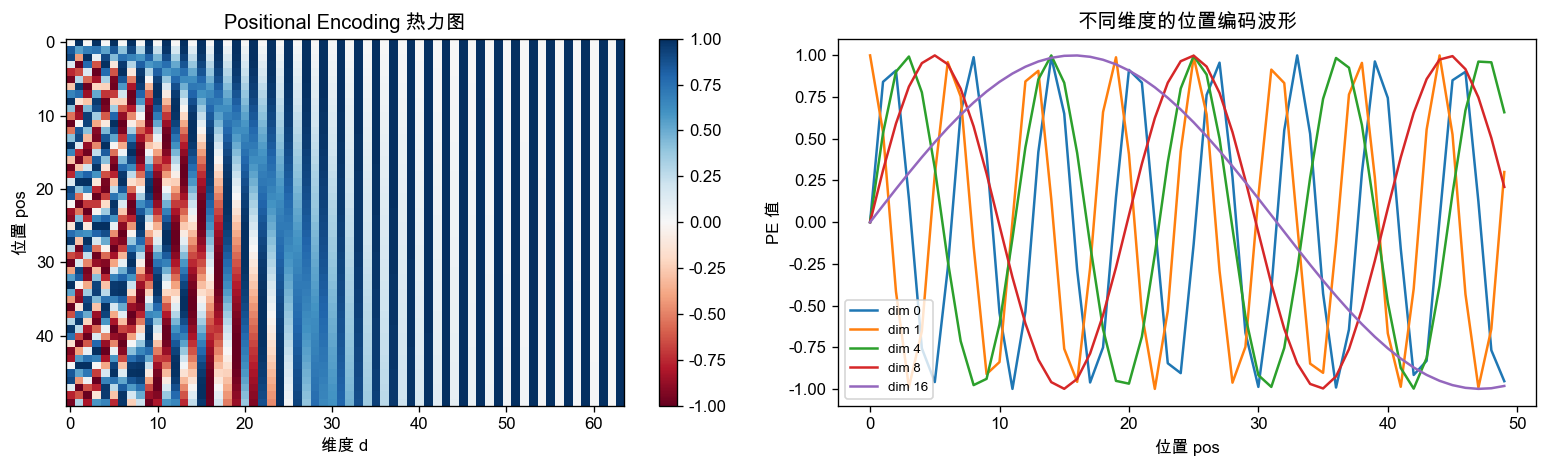

In [8]:
def positional_encoding(max_len, d_model):
    PE = np.zeros((max_len, d_model))
    pos = np.arange(max_len).reshape(-1, 1)
    i   = np.arange(d_model // 2).reshape(1, -1)
    angles = pos / (10000 ** (2 * i / d_model))
    PE[:, 0::2] = np.sin(angles)
    PE[:, 1::2] = np.cos(angles)
    return PE

pe = positional_encoding(50, 64)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
im = axes[0].imshow(pe, cmap='RdBu', aspect='auto', vmin=-1, vmax=1)
axes[0].set_xlabel('维度 d'); axes[0].set_ylabel('位置 pos')
axes[0].set_title('Positional Encoding 热力图')
plt.colorbar(im, ax=axes[0])

for dim in [0, 1, 4, 8, 16]:
    axes[1].plot(pe[:, dim], label=f'dim {dim}')
axes[1].set_xlabel('位置 pos'); axes[1].set_ylabel('PE 值')
axes[1].set_title('不同维度的位置编码波形')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

### 3.4 Feed-Forward Network (FFN)

每个 Attention 子层之后都跟一个 **逐位置** 的全连接网络：

$$\text{FFN}(x) = \max(0,\; xW_1 + b_1)\,W_2 + b_2$$

- 中间维度扩大 4 倍：$d_{\text{model}}=512 \to d_{ff}=2048$
- **Attention 负责「在哪里聚合信息」，FFN 负责「对聚合后的信息做非线性变换」**
- 各位置独立计算，天然可并行

---
## 4. 并行计算的优势

### 4.1 RNN 必须串行 vs Transformer 可以全并行

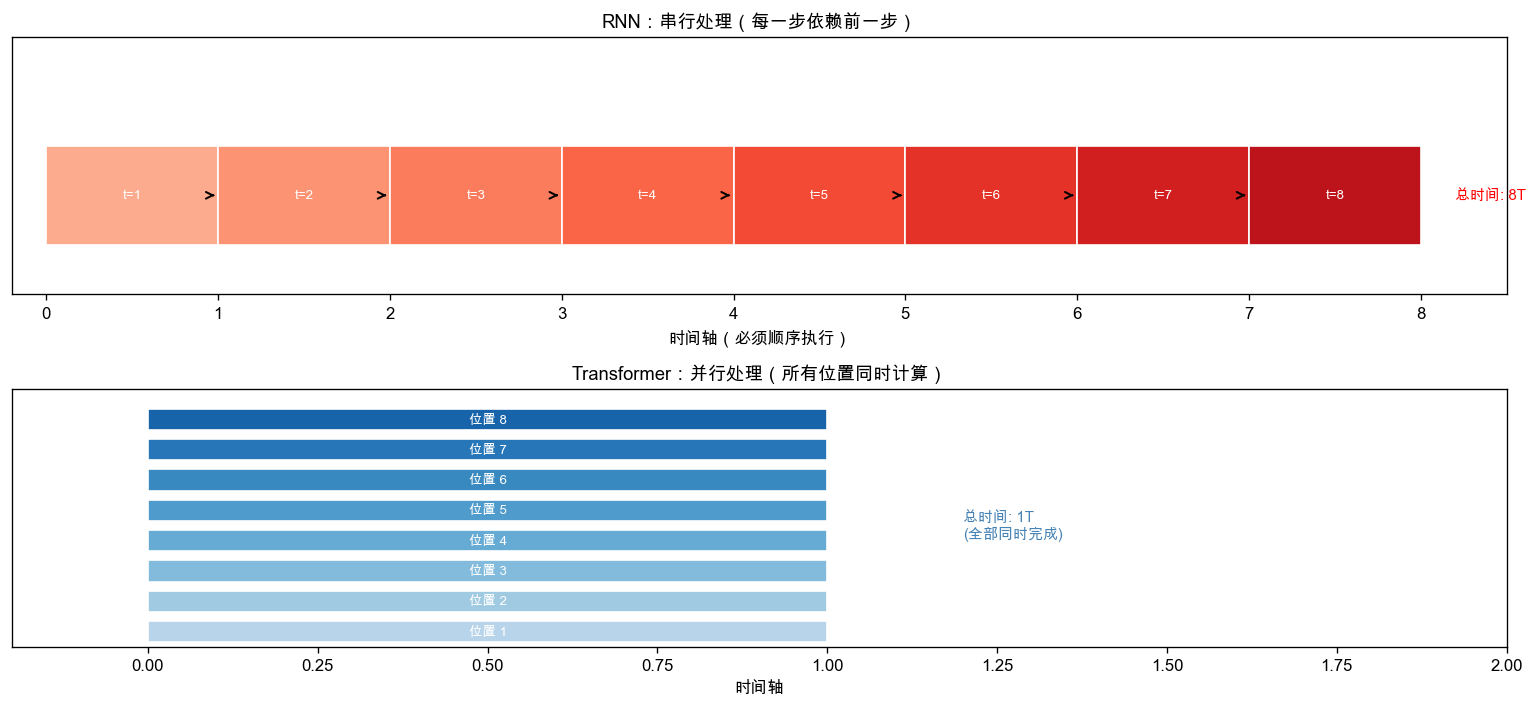

In [9]:
# ── 可视化 RNN 串行 vs Transformer 并行 ──
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 6))

n = 8  # 序列长度
colors_rnn   = plt.cm.Reds(np.linspace(0.3, 0.8, n))
colors_trans = plt.cm.Blues(np.linspace(0.3, 0.8, n))

# RNN: 时间步串行（第 t 步必须等第 t-1 步完成）
ax1.set_title('RNN：串行处理（每一步依赖前一步）', fontsize=11)
for i in range(n):
    ax1.barh(0, 1, left=i, height=0.5, color=colors_rnn[i], edgecolor='white')
    ax1.text(i + 0.5, 0, f't={i+1}', ha='center', va='center', color='white', fontsize=8)
    if i < n - 1:
        ax1.annotate('', xy=(i+1, 0), xytext=(i+0.95, 0),
                     arrowprops=dict(arrowstyle='->', color='black', lw=1.2))
ax1.set_xlim(-0.2, n + 0.5)
ax1.set_ylim(-0.5, 0.8)
ax1.set_xlabel('时间轴（必须顺序执行）')
ax1.set_yticks([])
ax1.text(n + 0.2, 0, f'总时间: {n}T', va='center', color='red', fontsize=9)

# Transformer: 所有位置同时计算
ax2.set_title('Transformer：并行处理（所有位置同时计算）', fontsize=11)
for i in range(n):
    ax2.barh(i, 1, left=0, height=0.7, color=colors_trans[i], edgecolor='white')
    ax2.text(0.5, i, f'位置 {i+1}', ha='center', va='center', color='white', fontsize=8)
ax2.set_xlim(-0.2, 2)
ax2.set_ylim(-0.5, n)
ax2.set_xlabel('时间轴')
ax2.set_yticks([])
ax2.text(1.2, n//2 - 0.5, f'总时间: 1T\n(全部同时完成)', va='center', color='steelblue', fontsize=9)

plt.tight_layout()
plt.show()

### 4.2 矩阵运算天然适配 GPU

Self-Attention 的核心是两次矩阵乘法：

```python
scores = Q @ K.T      # (n, d_k) × (d_k, n) → (n, n)  —— 所有 Query×Key 同时算
output = scores @ V   # (n, n) × (n, d_v) → (n, d_v)  —— 所有位置加权求和同时算
```

GPU 专为大规模矩阵乘法设计，可以同时执行 $n \times n$ 个乘加操作。  
RNN 每步的隐状态更新是 $h_t = f(W_h h_{t-1} + W_x x_t)$，存在对 $h_{t-1}$ 的**数据依赖**，无法批量并行。

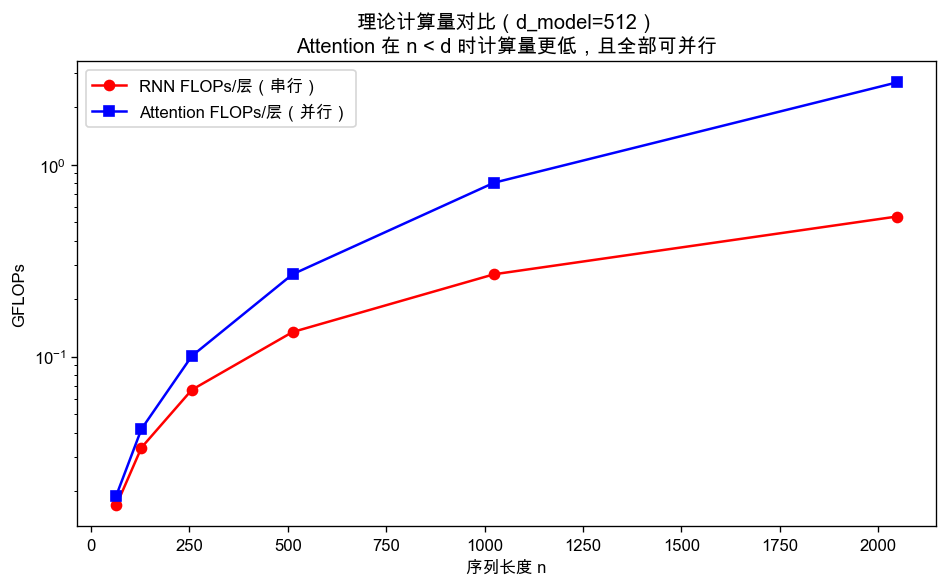

    序列长度 |   RNN GFLOPs |  Attn GFLOPs | Attn/RNN
--------------------------------------------------
      64 |        0.017 |        0.019 |     1.12x
     128 |        0.034 |        0.042 |     1.25x
     256 |        0.067 |        0.101 |     1.50x
     512 |        0.134 |        0.268 |     2.00x
    1024 |        0.268 |        0.805 |     3.00x
    2048 |        0.537 |        2.684 |     5.00x


In [10]:
# ── 计算复杂度对比（理论 FLOPs）──
import time

d = 512  # d_model
seq_lengths = [64, 128, 256, 512, 1024, 2048]

# 每层理论 FLOPs（简化）
rnn_ops  = [n * d**2 for n in seq_lengths]           # O(n·d²)，但串行
attn_ops = [n**2 * d + n * d**2 for n in seq_lengths] # O(n²d + nd²)，全并行

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(seq_lengths, [x/1e9 for x in rnn_ops],  'r-o', ms=6, label='RNN FLOPs/层（串行）')
ax.plot(seq_lengths, [x/1e9 for x in attn_ops], 'b-s', ms=6, label='Attention FLOPs/层（并行）')
ax.set_xlabel('序列长度 n')
ax.set_ylabel('GFLOPs')
ax.set_title(f'理论计算量对比（d_model={d}）\nAttention 在 n < d 时计算量更低，且全部可并行')
ax.legend()
ax.set_yscale('log')
plt.tight_layout()
plt.show()

print(f"{'序列长度':>8} | {'RNN GFLOPs':>12} | {'Attn GFLOPs':>12} | {'Attn/RNN':>8}")
print('-' * 50)
for n, r, a in zip(seq_lengths, rnn_ops, attn_ops):
    print(f"{n:>8} | {r/1e9:>12.3f} | {a/1e9:>12.3f} | {a/r:>8.2f}x")

### 4.3 训练并行 vs 推理串行

| 阶段 | RNN | Transformer |
|------|-----|-------------|
| **训练** | 串行，慢 | **全并行**（所有 token 同时处理）|
| **推理（生成）** | 串行（逐步生成）| 也是串行（自回归生成，每步需要前面的输出）|

> Transformer 的并行优势主要体现在**训练阶段**。  
> 推理阶段由于需要逐 token 生成，Transformer 和 RNN 都是串行的，但 Transformer 有 KV-Cache 可以加速。

---
## 总结

| 问题 | 核心答案 |
|------|----------|
| **Attention 怎么算** | $\text{softmax}(QK^T/\sqrt{d_k})V$，Q 查 K 得权重，加权求和 V |
| **为何替代 RNN** | 任意两位置路径长度 O(1)，无梯度消失，长距离依赖直接建模 |
| **模块堆叠** | Encoder: Self-Attn + FFN；Decoder: Masked-Attn + Cross-Attn + FFN；每层加残差 + LayerNorm |
| **并行优势** | 训练时所有位置同时计算，核心操作是矩阵乘法，天然适配 GPU |
